# iprPy bond_angle_scan calculation

In [1]:
# Standard library imports
import datetime
from math import floor

# http://www.numpy.org/
import numpy as np

# https://plotly.com/python
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty

# https://github.com/usnistgov/atomman 
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-06-25 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('bond_angle_scan')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# bond_angle_scan calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The bond_angle_scan calculation style evaluates the interaction energy between three atoms at varying distances and angles.  This provides a means of characterizing the three-body interactions of a given potential.  These interactions can provide insight into the bonding predictions for a potential as well as a means of fingerprinting the potentials.

### Version notes

- 2021-04-30: Calculation added.
- 2026-25-06: Method updated to support the LAMMPS library interface. Runs are also faster as a single LAMMPS instance is used.

### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)


## Method and Theory

Three atoms are placed in an otherwise empty system.  The relative positions of the atoms are determined by the following three coordinates

- r_ij is the radial distance between atoms i and j,
- r_ik is the radial distance between atoms i and k, and
- theta_ijk is the angle formed between the i-j and i-k vectors.

Based on these three bond coordinates, the full positions of the three atoms in the system are determined as follows

- Atom i is positioned at the system's origin, [0, 0, 0]
- Atom j is placed r_ij away from atom i along the x coordinate, [r_ij, 0.0, 0.0]
- Atom k is placed in the xy plane based on r_ik and theta_ijk, [r_ik cos(theta_ijk), r_ik sin(theta_ijk), 0.0]

Values of r_ij, r_ik and theta_ijk are iterated over. The potential energy of the three atoms is evaluated for each configuration corresponding to the different coordinate sets.


## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "bond_angle_scan.py"

# Python script created by Lucas Hale

# Standard Python libraries
from typing import Optional, Union

# http://www.numpy.org/
import numpy as np

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat
from atomman.lammps import LAMMPS, LAMMPSobj


def bond_angle_scan(lammps_command: Union[str, LAMMPSobj],
                    potential: lammpspotential, 
                    symbols: list,
                    mpi_command: Optional[str] = None,
                    rmin: unitfloat = '0.5 angstrom',
                    rmax: unitfloat = '6.0 angstrom',
                    rnum: int = 100,
                    thetamin: float = 1.0,
                    thetamax: float = 180,
                    thetanum: int = 100,
                    usefiles: bool = False) -> dict:
    """
    Performs a three-body bond angle energy scan over a range of interatomic
    spaces, r, and angles, theta.
    
    Parameters
    ----------
    lammps_command :str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    potential : PotentialLAMMPS or PotentialLAMMPSKIM
        The LAMMPS implemented potential to use.
    symbols : list
        The potential symbols associated with the three atoms in the cluster.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel.  If not given, LAMMPS
        will run serially.
    rmin : float or str, optional
        The minimum value for the r_ij and r_ik spacings. Default value is
        0.5 angstrom.
    rmax : float or str, optional
        The maximum value for the r_ij and r_ik spacings. Default value is
        6.0 angstrom.
    rnum : int, optional
        The number of r_ij and r_ik spacings to evaluate. Default value is 100.
    thetamin : float, optional
        The minimum value for the theta angle. Default value is 1.0.
    thetamax : float, optional
        The maximum value for the theta angle in degrees. Default value is 180.0.
    thetanum : int, optional
        The number of theta angles to evaluate. Default value is 100.
    usefiles : bool, optional
        If set to True, then all input/output files for LAMMPS will be generated.
        Default value of False will minimize the files created.

    Returns
    -------
    dict
        Dictionary of results consisting of keys:
        
        - **'cluster'** (*atomman.cluster.BondAngleMap*) - Object that maps
          measured energies to r, theta coordinates, and contains built-in
          analysis tools.
        - **results_file'** (*str*) - File name containing the raw energy
          scan results.
        - **'length_unit'** (*str*) - Unit of length used in the results_file.
        - **'energy_unit'** (*str*) - Unit of energy used in the results_file.
    """
    # Create a LAMMPS object if needed
    lmp = LAMMPS(lammps_command, mpi_command=mpi_command, potential=potential)

    # Handle file generation settings
    if usefiles or not lmp.islib:
        logfile = 'log.lammps'
        script = 'bond_scan.in'
    else:
        logfile = None
        script = None

    # Convert values given with units if needed
    rmin = uc.set_in_units(rmin)
    rmax = uc.set_in_units(rmax)

    # Create cluster object
    cluster = am.cluster.BondAngleMap(rmin=rmin, rmax=rmax, rnum=rnum,
                                      thetamin=thetamin, thetamax=thetamax,
                                      thetanum=thetanum, symbols=symbols)

    # Identify atomic types for the cluster
    if len(cluster.symbols) == 1:
        natypes = 1
        atype = np.array([1,1,1])
        symbols = cluster.symbols
    elif len(cluster.symbols) == 3:
        symbols, atype = np.unique(cluster.symbols, return_inverse=True)
        atype += 1
        natypes = len(symbols)

    ####### LAMMPS simulation #######

    lmp.commands_string('\n# Specify loop ranges')
    lmp.cmd.va

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
#mpi_command = 'mpiexec -localonly 4'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

#### 2.3. Calculation-specific parameters

- __symbols__ is the element or set of three element model symbols to use for the cluster.
- __rmin__ is the minimum r_ij and r_ik spacing to use.
- __rmax__ is the maximum r_ij and r_ik spacing to use.
- __rnum__ is the number of r_ij and r_ik spacing steps to evaluate.

- __thetamin__ is the minimum theta angle to use.
- __thetamax__ is the maximum theta angle to use.
- __thetanum__ is the number of theta angle steps to evaluate.

In [8]:
symbols = 'Ni'

rmin = uc.set_in_units(0.02, 'angstrom')
rmax = uc.set_in_units(6.0, 'angstrom')
rnum = 20

thetamin = 1.0
thetamax = 180.0
thetanum = 20

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [9]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.bond_angle_scan.bond_angle_scan'

In [10]:
results_dict = calculation.calc(lammps_command, potential, symbols,
                                mpi_command = mpi_command,
                                rmin = rmin, rmax = rmax, rnum = rnum,
                                thetamin = thetamin, thetamax = thetamax, thetanum = thetanum)
print(results_dict.keys())

dict_keys(['cluster', 'results_file', 'length_unit', 'energy_unit'])


### 4.2. Report results

Values returned in the results_dict:
- **'cluster'** (*atomman.cluster.BondAngleMap*) - An object containing the evaluated energies and their coordinates.  Includes built-in methods for analyzing the results.
- **'results_file'** (*str*) - The name of the file where the measured energies are saved.
- **'length_unit'** (*str*) - The unit of length used in results_file.
- **'energy_unit'** (*str*) - The unit of energy used in results_file.

In [11]:
print('Results are saved in', results_dict['results_file'])
print('with lengths in', results_dict['length_unit'])
print('and energies in', results_dict['energy_unit'])

Results are saved in 3_body_scan.txt
with lengths in angstrom
and energies in eV


In [12]:
cluster = results_dict['cluster']

cluster.df

,r_ij,r_ik,r_jk,theta,energy
0,0.02,0.02,0.000349,1.000000,9.662228e+02
1,0.02,0.02,0.003633,10.421053,9.644323e+02
2,0.02,0.02,0.006892,19.842105,9.626081e+02
3,0.02,0.02,0.010104,29.263158,9.608158e+02
4,0.02,0.02,0.013248,38.684211,9.590673e+02
...,...,...,...,...,...
7995,6.00,6.00,11.356946,142.315789,-9.291009e-11
7996,6.00,6.00,11.636851,151.736842,-9.291009e-11
7997,6.00,6.00,11.838145,161.157895,-9.291009e-11
7998,6.00,6.00,11.959468,170.578947,-9.291009e-11


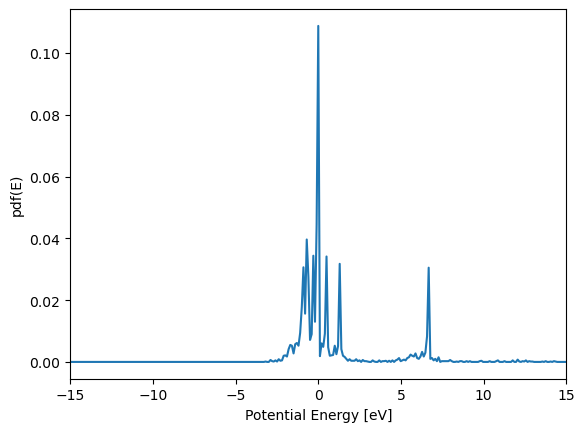

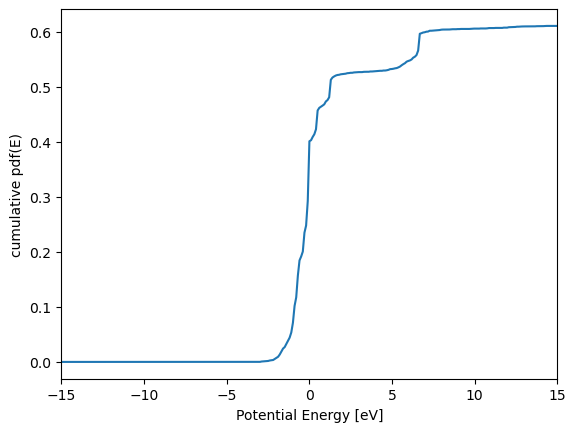

In [13]:
cluster.plot_pdf()
cluster.plot_cumulative_pdf()
None

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [14]:
calculation.clean_files()